<a href="https://colab.research.google.com/github/shreyaaaadalviiii/EV-Charging-Demand-Forecasting/blob/main/EV_Charging_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [8]:
df = pd.read_csv(
    "/content/EV_Charging_Grid_Optimization_Categorical.csv"
)

print(df.shape)

print(df.info())

print(df.isnull().sum())

(1000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   timestamp                    1000 non-null   object 
 1   station_id                   1000 non-null   int64  
 2   location                     1000 non-null   object 
 3   charging_type                1000 non-null   object 
 4   num_chargers                 1000 non-null   int64  
 5   voltage_level                1000 non-null   float64
 6   current_flow                 1000 non-null   float64
 7   power_consumed               1000 non-null   float64
 8   power_loss                   1000 non-null   float64
 9   voltage_fluctuation          1000 non-null   float64
 10  ev_id                        1000 non-null   int64  
 11  battery_capacity             1000 non-null   float64
 12  charging_time                1000 non-null   float64
 13  charging

In [9]:
df["ChargingEfficiency"] = (

    df["charging_power"]

    /

    (df["power_consumed"] + 0.01)

)

In [10]:
df["PowerLossPercent"] = (

    df["power_loss"]

    /

    (df["power_consumed"] + 0.01)

) * 100

In [11]:
df["CostPerUnit"] = (

    df["charging_cost"]

    /

    (df["power_consumed"] + 0.01)

)

In [12]:
df["CostPerUnit"] = (

    df["charging_cost"]

    /

    (df["power_consumed"] + 0.01)

)

In [13]:
station_power = (

    df.groupby("station_id")

    ["power_consumed"]

    .sum()

    .sort_values(
        ascending=False
    )
)

In [14]:
revenue = (

    df.groupby("location")

    ["charging_cost"]

    .sum()

)

<Axes: xlabel='voltage_stability_category', ylabel='grid_stability_score'>

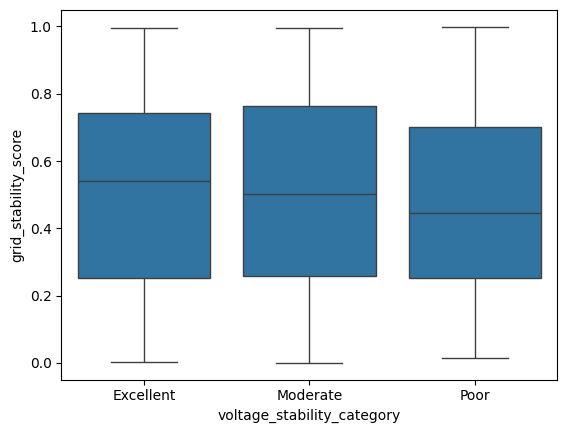

In [15]:
sns.boxplot(

    x="voltage_stability_category",

    y="grid_stability_score",

    data=df

)

<Axes: xlabel='power_consumed', ylabel='power_loss'>

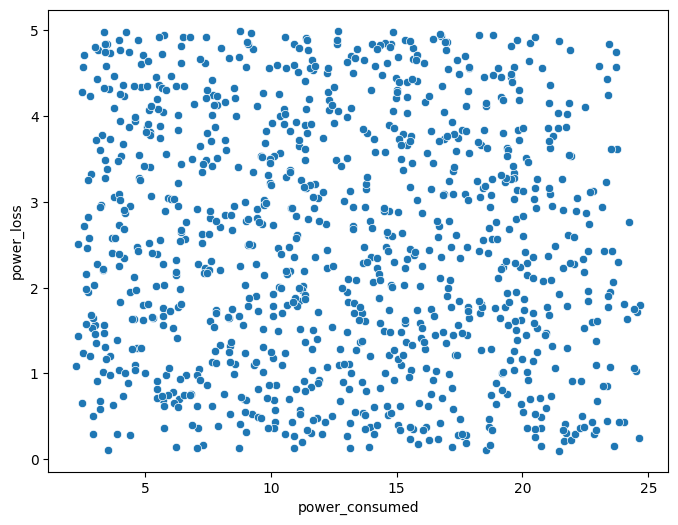

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    x="power_consumed",

    y="power_loss",

    data=df

)

In [17]:
charging = (

    df.groupby("charging_type")

    ["charging_power"]

    .mean()

)

In [25]:
from sklearn.model_selection import train_test_split

X = df[[
    'voltage_level',
    'current_flow',
    'power_consumed',
    'charging_time',
    'battery_capacity',
    'charging_power',
    'num_chargers'
]]

y = df['predicted_power_demand']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestRegressor

In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_estimators=500, random_state=42)

In [29]:
pred = model.predict(X_test)

In [30]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )
)

print(
    "R²:",
    r2_score(
        y_test,
        pred
    )
)

MAE: 0.27543600768488724
RMSE: 0.3301355563926956
R²: 0.9970332788204104


In [31]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    model.feature_importances_

})

In [32]:
df["OptimizationGain"] = (

    df["charging_power"]

    -

    df["optimized_charging_power"]

)

In [33]:
joblib.dump(

    model,

    "power_demand_model.pkl"

)

['power_demand_model.pkl']